# Binary Classification with Neural Networks (Circles Dataset)

## Objective :
The goal of this assignment is to build, train, evaluate, and compare different Artificial Neural Network (ANN) architectures using PyTorch to classify a non-linear dataset consisting of two concentric circles.

This task demonstrates how model architecture, activation functions, and optimizers influence the ability of neural networks to learn complex patterns.

## Setup and Imports

We import the required libraries for:

- Data handling → pandas, NumPy  
- Visualization → matplotlib  
- Deep learning → PyTorch  
- Data splitting → scikit-learn  

Warnings are suppressed for cleaner output.

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


## 1. Data Retrieval & Inspection

The dataset contains:

- Two input features: **X1 and X2**
- One binary target label

The data represents two concentric circles belonging to different classes.  
This makes the dataset **non-linearly separable**, meaning a straight line cannot separate the classes.

Steps performed:
- Load the dataset
- Inspect shape and structure
- View summary statistics
- Check class distribution

In [2]:
# Load the dataset
df = pd.read_csv('Assignment/circles_binary_classification.csv')

print("Dataset Shape:", df.shape)
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print()
df.head()

Dataset Shape: (1000, 3)
Number of samples: 1000
Number of features: 3



,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [3]:
# Statistical summary
df.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


In [4]:
# Check class distribution
print("Label distribution:")
print(df['label'].value_counts())
print(f"\nClass balance: {df['label'].value_counts(normalize=True).to_dict()}")

Label distribution:
label
1    500
0    500
Name: count, dtype: int64

Class balance: {1: 0.5, 0: 0.5}


## 2. Data Cleaning & Feature Design

### Data Cleaning
We verify data quality by checking:

- Missing values  
- Data types  

No preprocessing is required if the dataset is already clean.

### Feature Design
We separate:

- **Features (X)** → X1 and X2  
- **Target (y)** → label  

The data is converted into PyTorch tensors so it can be used for neural network training.

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nData types:")
print(df.dtypes)
print("\nConclusion: The data is clean. No missing values and all types are correct.")

Missing values per column:
X1       0
X2       0
label    0
dtype: int64

Total missing values: 0

Data types:
X1       float64
X2       float64
label      int64
dtype: object

Conclusion: The data is clean. No missing values and all types are correct.


In [6]:
# Create X (features) and y (labels) as NumPy arrays
X = df[['X1', 'X2']].values
y = df['label'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

X shape: (1000, 2)
y shape: (1000,)

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [7]:
# Convert to PyTorch tensors with correct dtypes
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

print(f"X dtype: {X.dtype}, shape: {X.shape}")
print(f"y dtype: {y.dtype}, shape: {y.shape}")
print(f"\nFirst 5 X tensors:\n{X[:5]}")
print(f"First 5 y tensors:\n{y[:5]}")

X dtype: torch.float32, shape: torch.Size([1000, 2])
y dtype: torch.float32, shape: torch.Size([1000])

First 5 X tensors:
tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])
First 5 y tensors:
tensor([1., 1., 1., 1., 0.])


## 3. Data Visualization

We plot X1 vs X2 using a scatter plot, colored by class label.

This visualization helps us understand the structure of the data.  
The plot clearly shows two circular regions, confirming that the problem is non-linear.

A linear classifier will not be sufficient for this task.

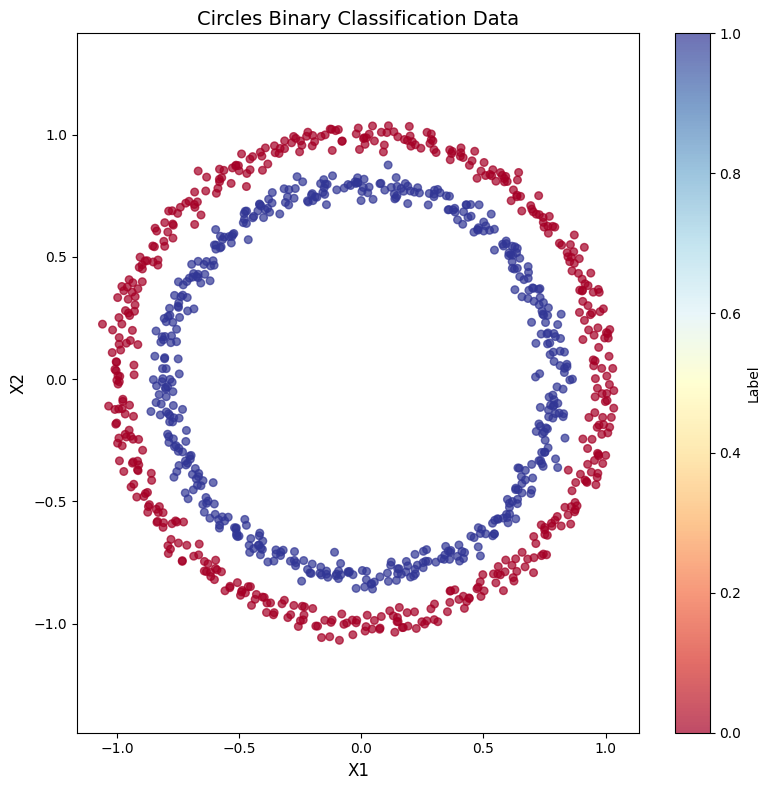

In [8]:
plt.figure(figsize=(8, 8))
plt.scatter(x=df['X1'], y=df['X2'], c=df['label'], cmap=plt.cm.RdYlBu, s=30, alpha=0.7)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Circles Binary Classification Data', fontsize=14)
plt.colorbar(label='Label')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 4. Train/Test Split

The dataset is divided into:

- 80% training data  
- 20% testing data  

A fixed random state ensures reproducibility.

Training data is used for learning model parameters, while testing data evaluates generalization performance.

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")

Training samples: 800
Testing samples:  200
Training features shape: torch.Size([800, 2])
Testing features shape:  torch.Size([200, 2])


## 5. Device and Data Type Setup

The code is written to be device-agnostic:

- Uses GPU (CUDA) if available  
- Otherwise uses CPU  

All tensors are moved to the selected device to ensure consistent computation.

In [10]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Move data to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"X_train device: {X_train.device}")
print(f"y_train device: {y_train.device}")

Using device: cpu
X_train device: cpu
y_train device: cpu


## 6. Helper Functions

Reusable utilities are defined:

- Accuracy calculation  
- Training and testing loop  
- Decision boundary visualization  
- Loss and accuracy curve plotting  

These functions allow consistent evaluation across different model architectures.

In [11]:
# Accuracy function
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions."""
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [12]:
# Reusable training and testing loop
def train_and_test_loop(
    model: nn.Module,
    epochs: int,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_test: torch.Tensor,
    y_test: torch.Tensor,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer
):
    loss_list = []
    acc_list = []
    test_losses = []
    test_acc_list = []

    for epoch in range(epochs):
        ### Training
        model.train()

        # Forward pass (raw logits)
        y_logits = model(X_train).squeeze()
        y_pred = torch.round(torch.sigmoid(y_logits))

        # Calculate loss and accuracy
        loss = loss_fn(y_logits, y_train)
        acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### Testing
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            test_loss = loss_fn(test_logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

        # Record metrics
        loss_list.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc_list.append(test_acc)

        # Print progress every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

    return loss_list, acc_list, test_losses, test_acc_list

In [13]:
# Decision boundary plotting function
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y."""
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))

    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [14]:
# Loss curve plotting function
def plot_loss_curves(train_losses, test_losses, title=""):
    """Plots training and testing loss curves."""
    epochs = range(len(train_losses))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curves{' - ' + title if title else ''}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_acc_curves(train_acc, test_acc, title=""):
    """Plots training and testing accuracy curves."""
    epochs = range(len(train_acc))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Training Accuracy")
    plt.plot(epochs, test_acc, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy Curves{' - ' + title if title else ''}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. ModelV0 — Baseline Linear Network

Architecture:
2 → 5 → 1 (no activation function)

This model contains only linear transformations.  
Stacking linear layers is mathematically equivalent to a single linear layer.

Therefore, the model can only learn a **linear decision boundary**, which is insufficient for circular data.

Loss function:
Binary Cross Entropy with logits.

Optimizer:
Stochastic Gradient Descent (SGD).

In [15]:
# Define ModelV0: 2 -> 5 -> 1 (no activation)
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

# Instantiate and inspect
torch.manual_seed(42)
model_v0 = ModelV0().to(device)
print(model_v0)
print(f"\nTotal parameters: {sum(p.numel() for p in model_v0.parameters())}")

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

Total parameters: 21


In [16]:
# Show untrained predictions
with torch.inference_mode():
    untrained_preds_v0 = model_v0(X_test.to(device))
print(f"Untrained predictions (first 10 logits):\n{untrained_preds_v0[:10].squeeze()}")
print(f"\nUntrained predicted labels (first 10):\n{torch.round(torch.sigmoid(untrained_preds_v0[:10].squeeze()))}")
print(f"Actual labels (first 10):\n{y_test[:10]}")

Untrained predictions (first 10 logits):
tensor([-0.1269, -0.0967, -0.1908, -0.1089, -0.1667, -0.1484, -0.0826, -0.0946,
        -0.1918, -0.0944])

Untrained predicted labels (first 10):
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Actual labels (first 10):
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [17]:
# Train ModelV0
torch.manual_seed(42)
model_v0 = ModelV0().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v0 = torch.optim.SGD(params=model_v0.parameters(), lr=0.1)
epochs_v0 = 100

print(f"Training ModelV0 for {epochs_v0} epochs...")
print("=" * 80)
train_losses_v0, train_acc_v0, test_losses_v0, test_acc_v0 = train_and_test_loop(
    model=model_v0, epochs=epochs_v0,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    loss_fn=loss_fn, optimizer=optimizer_v0
)

Training ModelV0 for 100 epochs...
Epoch: 0 | Loss: 0.69569, Accuracy: 50.00% | Test loss: 0.69721, Test acc: 50.00%
Epoch: 10 | Loss: 0.69403, Accuracy: 50.00% | Test loss: 0.69615, Test acc: 50.00%
Epoch: 20 | Loss: 0.69343, Accuracy: 46.00% | Test loss: 0.69585, Test acc: 48.50%
Epoch: 30 | Loss: 0.69321, Accuracy: 49.00% | Test loss: 0.69577, Test acc: 47.50%
Epoch: 40 | Loss: 0.69312, Accuracy: 49.50% | Test loss: 0.69573, Test acc: 46.50%
Epoch: 50 | Loss: 0.69308, Accuracy: 50.38% | Test loss: 0.69569, Test acc: 46.50%
Epoch: 60 | Loss: 0.69306, Accuracy: 50.50% | Test loss: 0.69564, Test acc: 46.50%
Epoch: 70 | Loss: 0.69305, Accuracy: 50.50% | Test loss: 0.69559, Test acc: 46.50%
Epoch: 80 | Loss: 0.69304, Accuracy: 50.75% | Test loss: 0.69553, Test acc: 46.50%
Epoch: 90 | Loss: 0.69303, Accuracy: 50.38% | Test loss: 0.69547, Test acc: 46.50%


### ModelV0: Predictions & Decision Boundary

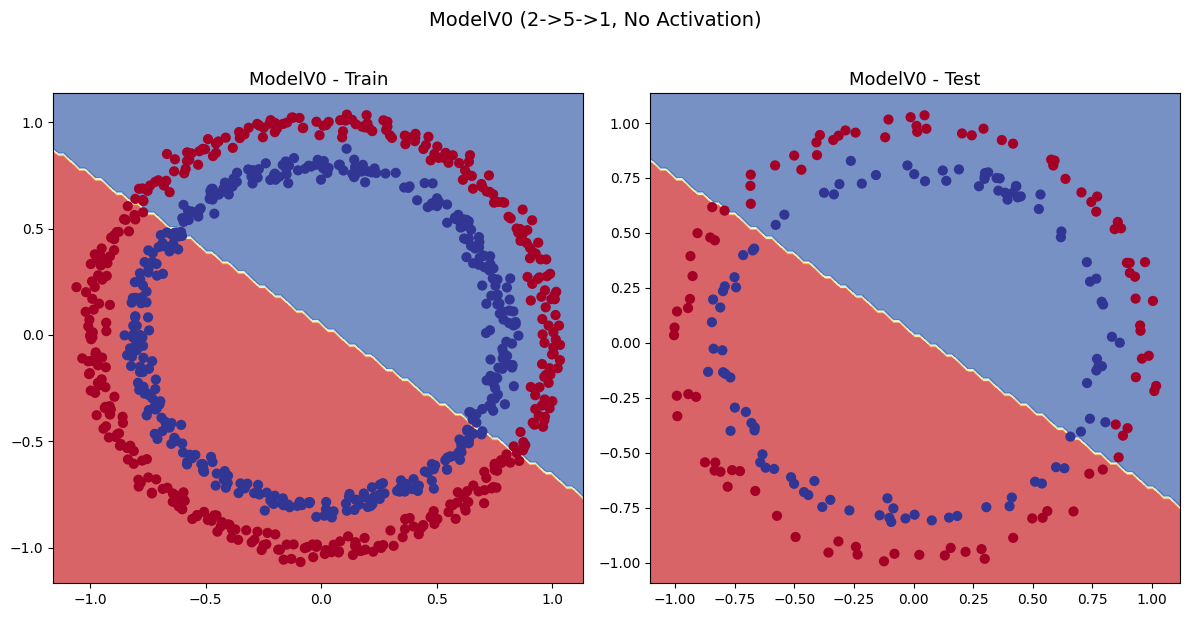

In [18]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("ModelV0 - Train", fontsize=13)
plot_decision_boundary(model_v0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("ModelV0 - Test", fontsize=13)
plot_decision_boundary(model_v0, X_test, y_test)
plt.suptitle("ModelV0 (2->5->1, No Activation)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Move model back to device after plot_decision_boundary moves it to CPU
model_v0.to(device);

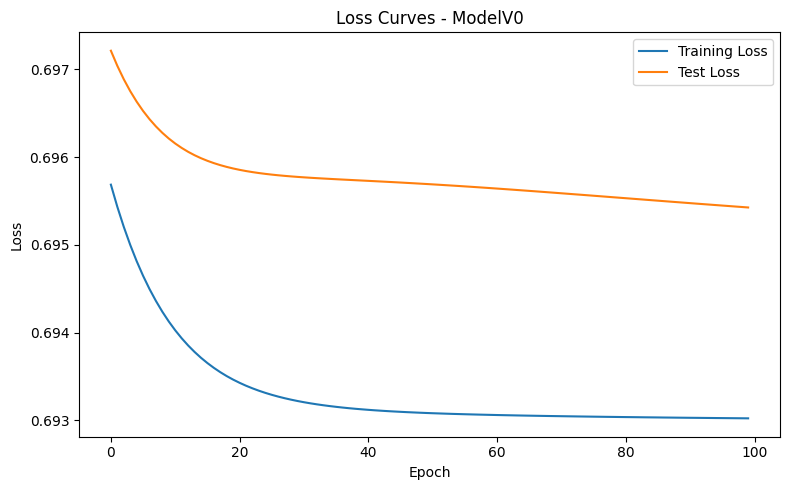

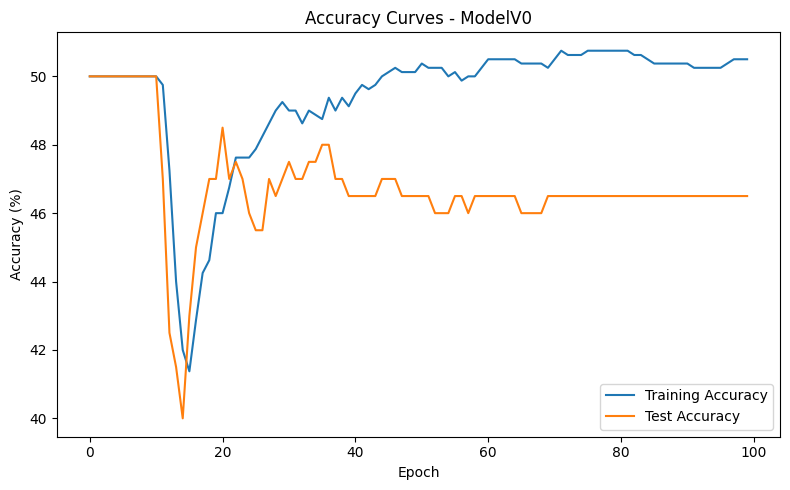

In [19]:
# Plot loss and accuracy curves
plot_loss_curves(train_losses_v0, test_losses_v0, title="ModelV0")
plot_acc_curves(train_acc_v0, test_acc_v0, title="ModelV0")

### ModelV0 Results and Analysis

The model underfits the data.

Because it cannot represent non-linear relationships, it fails to separate the inner and outer circles.  
Accuracy remains close to random guessing.

This confirms that linear models cannot solve non-linear classification problems.

## 8. ModelV1 — Deeper Linear Network

Architecture:
2 → 15 → 15 → 1 (no activation function)

This model increases depth and number of parameters.  
However, it still contains no activation functions.

Multiple linear layers still combine into a single linear transformation.  
Therefore, the model remains incapable of learning non-linear boundaries.

In [20]:
# Define ModelV1: 2 -> 15 -> 15 -> 1 (no activation)
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=15)
        self.layer_2 = nn.Linear(in_features=15, out_features=15)
        self.layer_3 = nn.Linear(in_features=15, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

# Instantiate
torch.manual_seed(42)
model_v1 = ModelV1().to(device)
print(model_v1)
print(f"\nTotal parameters: {sum(p.numel() for p in model_v1.parameters())}")

ModelV1(
  (layer_1): Linear(in_features=2, out_features=15, bias=True)
  (layer_2): Linear(in_features=15, out_features=15, bias=True)
  (layer_3): Linear(in_features=15, out_features=1, bias=True)
)

Total parameters: 301


In [21]:
# Show untrained predictions
with torch.inference_mode():
    untrained_preds_v1 = model_v1(X_test.to(device))
print(f"Untrained predictions (first 10 logits):\n{untrained_preds_v1[:10].squeeze()}")
print(f"\nUntrained predicted labels (first 10):\n{torch.round(torch.sigmoid(untrained_preds_v1[:10].squeeze()))}")
print(f"Actual labels (first 10):\n{y_test[:10]}")

Untrained predictions (first 10 logits):
tensor([0.1579, 0.1511, 0.1598, 0.1574, 0.1348, 0.1308, 0.1317, 0.1269, 0.1608,
        0.1504])

Untrained predicted labels (first 10):
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Actual labels (first 10):
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [22]:
# Train ModelV1
torch.manual_seed(42)
model_v1 = ModelV1().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v1 = torch.optim.SGD(params=model_v1.parameters(), lr=0.1)
epochs_v1 = 1000

print(f"Training ModelV1 for {epochs_v1} epochs...")
print("=" * 80)
train_losses_v1, train_acc_v1, test_losses_v1, test_acc_v1 = train_and_test_loop(
    model=model_v1, epochs=epochs_v1,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    loss_fn=loss_fn, optimizer=optimizer_v1
)

Training ModelV1 for 1000 epochs...
Epoch: 0 | Loss: 0.69588, Accuracy: 50.00% | Test loss: 0.69540, Test acc: 50.00%
Epoch: 10 | Loss: 0.69357, Accuracy: 50.00% | Test loss: 0.69407, Test acc: 50.00%
Epoch: 20 | Loss: 0.69313, Accuracy: 55.38% | Test loss: 0.69402, Test acc: 51.50%
Epoch: 30 | Loss: 0.69304, Accuracy: 52.00% | Test loss: 0.69413, Test acc: 49.00%
Epoch: 40 | Loss: 0.69301, Accuracy: 51.38% | Test loss: 0.69424, Test acc: 48.00%
Epoch: 50 | Loss: 0.69300, Accuracy: 51.12% | Test loss: 0.69432, Test acc: 47.00%
Epoch: 60 | Loss: 0.69299, Accuracy: 50.88% | Test loss: 0.69439, Test acc: 47.00%
Epoch: 70 | Loss: 0.69299, Accuracy: 51.00% | Test loss: 0.69444, Test acc: 47.00%
Epoch: 80 | Loss: 0.69299, Accuracy: 51.12% | Test loss: 0.69449, Test acc: 47.00%
Epoch: 90 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69452, Test acc: 47.00%
Epoch: 100 | Loss: 0.69298, Accuracy: 51.25% | Test loss: 0.69455, Test acc: 46.50%


Epoch: 110 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69458, Test acc: 46.50%


Epoch: 120 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69460, Test acc: 46.00%


Epoch: 130 | Loss: 0.69298, Accuracy: 51.25% | Test loss: 0.69461, Test acc: 46.00%
Epoch: 140 | Loss: 0.69298, Accuracy: 51.38% | Test loss: 0.69462, Test acc: 46.00%
Epoch: 150 | Loss: 0.69298, Accuracy: 51.38% | Test loss: 0.69463, Test acc: 46.00%
Epoch: 160 | Loss: 0.69298, Accuracy: 51.50% | Test loss: 0.69464, Test acc: 46.00%
Epoch: 170 | Loss: 0.69298, Accuracy: 51.38% | Test loss: 0.69465, Test acc: 45.50%
Epoch: 180 | Loss: 0.69298, Accuracy: 51.38% | Test loss: 0.69466, Test acc: 44.50%
Epoch: 190 | Loss: 0.69298, Accuracy: 51.50% | Test loss: 0.69466, Test acc: 44.50%
Epoch: 200 | Loss: 0.69298, Accuracy: 51.62% | Test loss: 0.69466, Test acc: 45.00%


Epoch: 210 | Loss: 0.69298, Accuracy: 51.38% | Test loss: 0.69467, Test acc: 45.00%


...

Epoch: 830 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 840 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 850 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 860 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Epoch: 870 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 880 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 890 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 910 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Epoch: 920 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Epoch: 930 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 940 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 950 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Epoch: 960 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 970 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 980 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 990 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


### ModelV1: Predictions & Decision Boundary

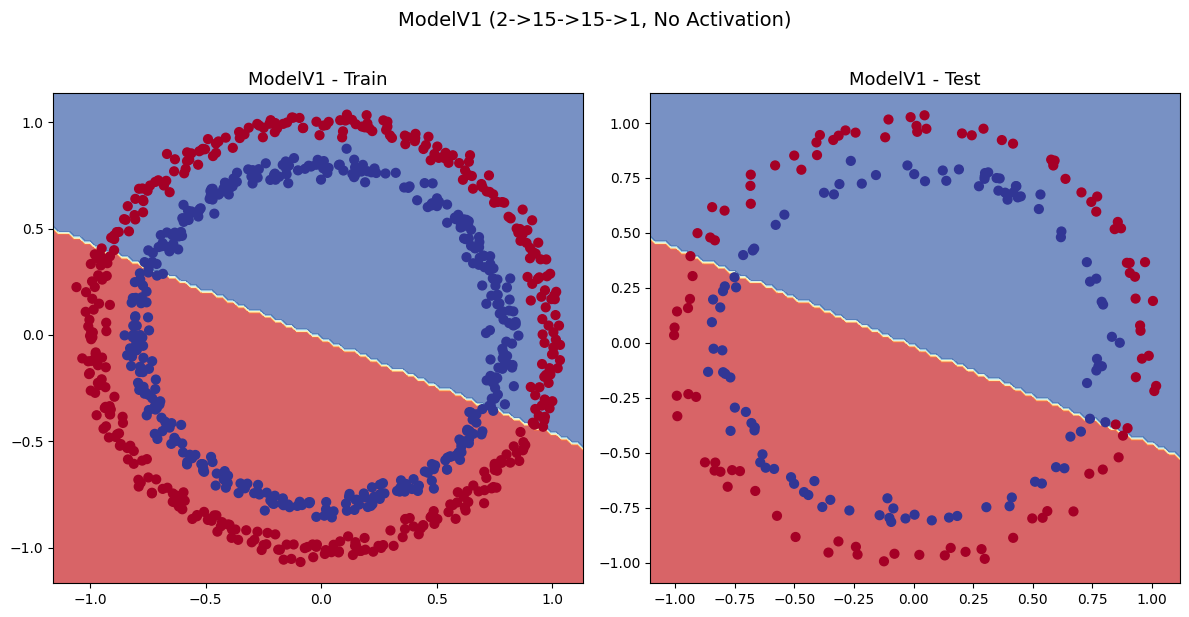

In [23]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("ModelV1 - Train", fontsize=13)
plot_decision_boundary(model_v1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("ModelV1 - Test", fontsize=13)
plot_decision_boundary(model_v1, X_test, y_test)
plt.suptitle("ModelV1 (2->15->15->1, No Activation)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

model_v1.to(device);

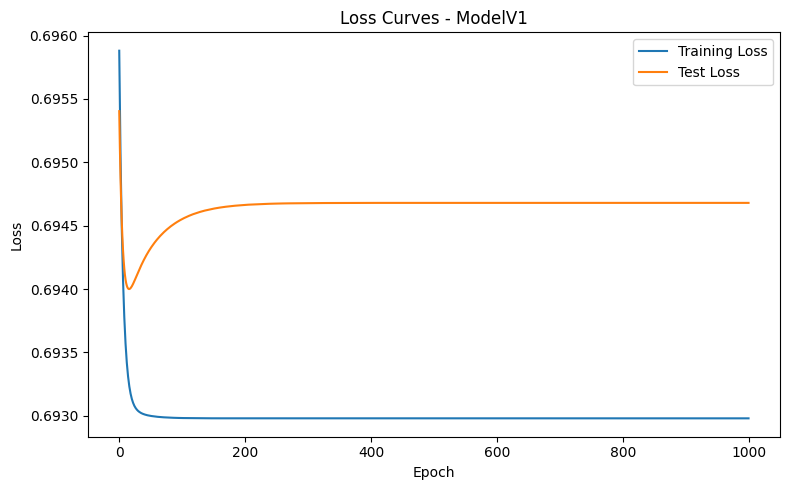

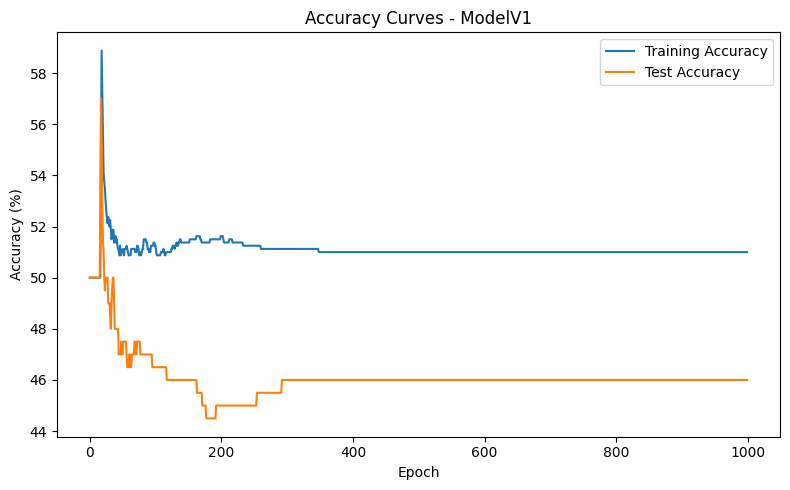

In [24]:
# Plot loss and accuracy curves
plot_loss_curves(train_losses_v1, test_losses_v1, title="ModelV1")
plot_acc_curves(train_acc_v1, test_acc_v1, title="ModelV1")

### ModelV1 Results and Analysis

Despite having more layers and neurons, the model still underfits.

Increasing model size without introducing non-linearity does not improve performance.  
The decision boundary remains linear.

This demonstrates that **model depth alone does not create learning power**.

## 9. ModelV2 — Non-Linear Neural Network

Architecture:
2 → 64 → 64 → 10 → 1 with ReLU activation

ReLU introduces non-linearity by transforming inputs using max(0, x).  
This allows the network to learn complex shapes and curved boundaries.

This model is capable of separating circular data.

In [25]:
# Define ModelV2: 2 -> 64 -> 64 -> 10 -> 1 with ReLU activations
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=64)
        self.layer_2 = nn.Linear(in_features=64, out_features=64)
        self.layer_3 = nn.Linear(in_features=64, out_features=10)
        self.layer_4 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        return self.layer_4(x)  # raw logits, no sigmoid here

# Instantiate
torch.manual_seed(42)
model_v2 = ModelV2().to(device)
print(model_v2)
print(f"\nTotal parameters: {sum(p.numel() for p in model_v2.parameters())}")

ModelV2(
  (layer_1): Linear(in_features=2, out_features=64, bias=True)
  (layer_2): Linear(in_features=64, out_features=64, bias=True)
  (layer_3): Linear(in_features=64, out_features=10, bias=True)
  (layer_4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 5013


In [26]:
# Show untrained predictions
with torch.inference_mode():
    untrained_preds_v2 = model_v2(X_test.to(device))
print(f"Untrained predictions (first 10 logits):\n{untrained_preds_v2[:10].squeeze()}")
print(f"\nUntrained predicted labels (first 10):\n{torch.round(torch.sigmoid(untrained_preds_v2[:10].squeeze()))}")
print(f"Actual labels (first 10):\n{y_test[:10]}")

Untrained predictions (first 10 logits):
tensor([0.1692, 0.1595, 0.1518, 0.1713, 0.1185, 0.1099, 0.1085, 0.0924, 0.1533,
        0.1582])

Untrained predicted labels (first 10):
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Actual labels (first 10):
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [27]:
# Train ModelV2
torch.manual_seed(42)
model_v2 = ModelV2().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v2 = torch.optim.SGD(params=model_v2.parameters(), lr=0.1)
epochs_v2 = 1000

print(f"Training ModelV2 for {epochs_v2} epochs...")
print("=" * 80)
train_losses_v2, train_acc_v2, test_losses_v2, test_acc_v2 = train_and_test_loop(
    model=model_v2, epochs=epochs_v2,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    loss_fn=loss_fn, optimizer=optimizer_v2
)

Training ModelV2 for 1000 epochs...
Epoch: 0 | Loss: 0.69615, Accuracy: 50.00% | Test loss: 0.69561, Test acc: 50.00%
Epoch: 10 | Loss: 0.69370, Accuracy: 50.00% | Test loss: 0.69363, Test acc: 50.00%
Epoch: 20 | Loss: 0.69244, Accuracy: 56.50% | Test loss: 0.69263, Test acc: 56.50%
Epoch: 30 | Loss: 0.69172, Accuracy: 52.62% | Test loss: 0.69210, Test acc: 53.00%


Epoch: 40 | Loss: 0.69116, Accuracy: 51.75% | Test loss: 0.69174, Test acc: 51.00%
Epoch: 50 | Loss: 0.69066, Accuracy: 52.38% | Test loss: 0.69144, Test acc: 53.50%
Epoch: 60 | Loss: 0.69018, Accuracy: 53.25% | Test loss: 0.69112, Test acc: 53.50%
Epoch: 70 | Loss: 0.68961, Accuracy: 53.75% | Test loss: 0.69072, Test acc: 54.00%
Epoch: 80 | Loss: 0.68914, Accuracy: 54.25% | Test loss: 0.69041, Test acc: 53.50%


Epoch: 90 | Loss: 0.68866, Accuracy: 55.50% | Test loss: 0.69007, Test acc: 53.50%
Epoch: 100 | Loss: 0.68815, Accuracy: 57.12% | Test loss: 0.68971, Test acc: 54.50%
Epoch: 110 | Loss: 0.68760, Accuracy: 59.13% | Test loss: 0.68933, Test acc: 55.00%
Epoch: 120 | Loss: 0.68702, Accuracy: 60.38% | Test loss: 0.68892, Test acc: 57.00%
Epoch: 130 | Loss: 0.68638, Accuracy: 61.38% | Test loss: 0.68850, Test acc: 58.50%


Epoch: 140 | Loss: 0.68569, Accuracy: 63.25% | Test loss: 0.68803, Test acc: 61.00%
Epoch: 150 | Loss: 0.68493, Accuracy: 64.88% | Test loss: 0.68751, Test acc: 63.50%
Epoch: 160 | Loss: 0.68412, Accuracy: 65.62% | Test loss: 0.68693, Test acc: 62.50%
Epoch: 170 | Loss: 0.68325, Accuracy: 65.75% | Test loss: 0.68631, Test acc: 61.00%
Epoch: 180 | Loss: 0.68231, Accuracy: 66.38% | Test loss: 0.68564, Test acc: 61.00%


Epoch: 190 | Loss: 0.68131, Accuracy: 67.38% | Test loss: 0.68492, Test acc: 59.50%
Epoch: 200 | Loss: 0.68021, Accuracy: 67.88% | Test loss: 0.68413, Test acc: 60.50%
Epoch: 210 | Loss: 0.67899, Accuracy: 68.38% | Test loss: 0.68324, Test acc: 61.00%
Epoch: 220 | Loss: 0.67765, Accuracy: 70.00% | Test loss: 0.68226, Test acc: 62.50%
Epoch: 230 | Loss: 0.67612, Accuracy: 70.38% | Test loss: 0.68116, Test acc: 63.00%


...

Epoch: 790 | Loss: 0.02381, Accuracy: 100.00% | Test loss: 0.04367, Test acc: 100.00%
Epoch: 800 | Loss: 0.02233, Accuracy: 100.00% | Test loss: 0.04163, Test acc: 100.00%
Epoch: 810 | Loss: 0.02100, Accuracy: 100.00% | Test loss: 0.03979, Test acc: 100.00%
Epoch: 820 | Loss: 0.01981, Accuracy: 100.00% | Test loss: 0.03811, Test acc: 100.00%
Epoch: 830 | Loss: 0.01874, Accuracy: 100.00% | Test loss: 0.03657, Test acc: 100.00%


Epoch: 840 | Loss: 0.01777, Accuracy: 100.00% | Test loss: 0.03519, Test acc: 100.00%
Epoch: 850 | Loss: 0.01689, Accuracy: 100.00% | Test loss: 0.03391, Test acc: 100.00%
Epoch: 860 | Loss: 0.01608, Accuracy: 100.00% | Test loss: 0.03273, Test acc: 100.00%
Epoch: 870 | Loss: 0.01534, Accuracy: 100.00% | Test loss: 0.03163, Test acc: 100.00%


Epoch: 880 | Loss: 0.01466, Accuracy: 100.00% | Test loss: 0.03059, Test acc: 100.00%
Epoch: 890 | Loss: 0.01403, Accuracy: 100.00% | Test loss: 0.02962, Test acc: 100.00%
Epoch: 900 | Loss: 0.01345, Accuracy: 100.00% | Test loss: 0.02873, Test acc: 100.00%
Epoch: 910 | Loss: 0.01291, Accuracy: 100.00% | Test loss: 0.02789, Test acc: 100.00%


Epoch: 920 | Loss: 0.01241, Accuracy: 100.00% | Test loss: 0.02711, Test acc: 100.00%
Epoch: 930 | Loss: 0.01194, Accuracy: 100.00% | Test loss: 0.02637, Test acc: 100.00%
Epoch: 940 | Loss: 0.01151, Accuracy: 100.00% | Test loss: 0.02568, Test acc: 100.00%
Epoch: 950 | Loss: 0.01110, Accuracy: 100.00% | Test loss: 0.02503, Test acc: 100.00%
Epoch: 960 | Loss: 0.01072, Accuracy: 100.00% | Test loss: 0.02442, Test acc: 100.00%


Epoch: 970 | Loss: 0.01035, Accuracy: 100.00% | Test loss: 0.02381, Test acc: 100.00%
Epoch: 980 | Loss: 0.01000, Accuracy: 100.00% | Test loss: 0.02325, Test acc: 100.00%
Epoch: 990 | Loss: 0.00968, Accuracy: 100.00% | Test loss: 0.02272, Test acc: 100.00%


### ModelV2: Predictions & Decision Boundary

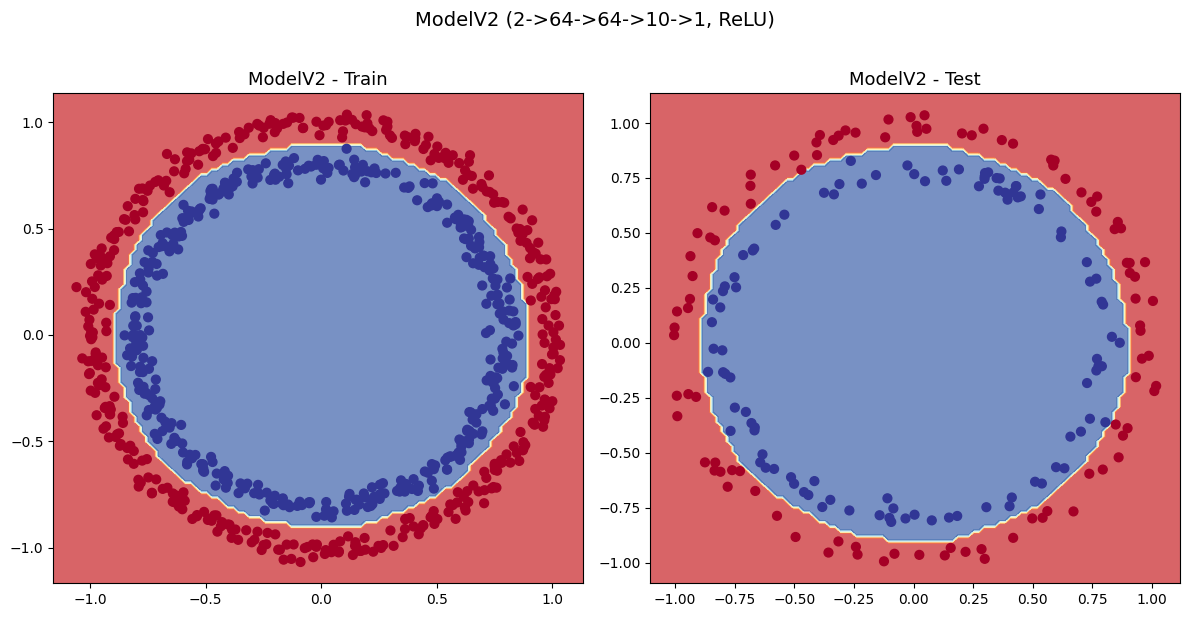

In [28]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("ModelV2 - Train", fontsize=13)
plot_decision_boundary(model_v2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("ModelV2 - Test", fontsize=13)
plot_decision_boundary(model_v2, X_test, y_test)
plt.suptitle("ModelV2 (2->64->64->10->1, ReLU)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

model_v2.to(device);

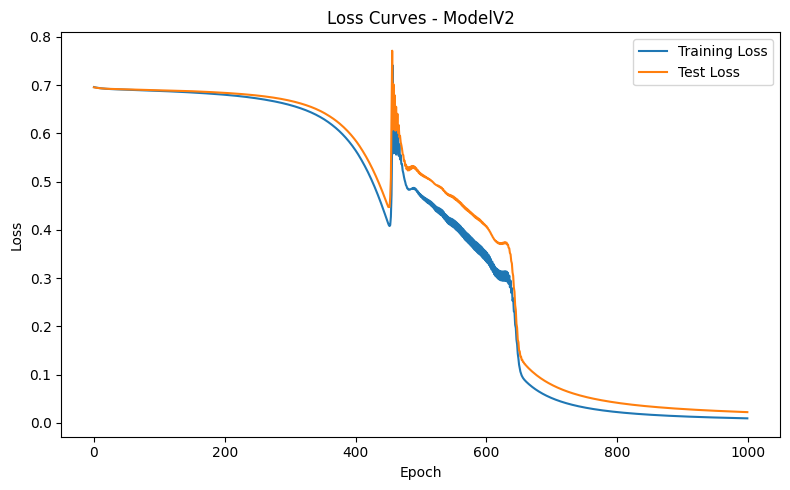

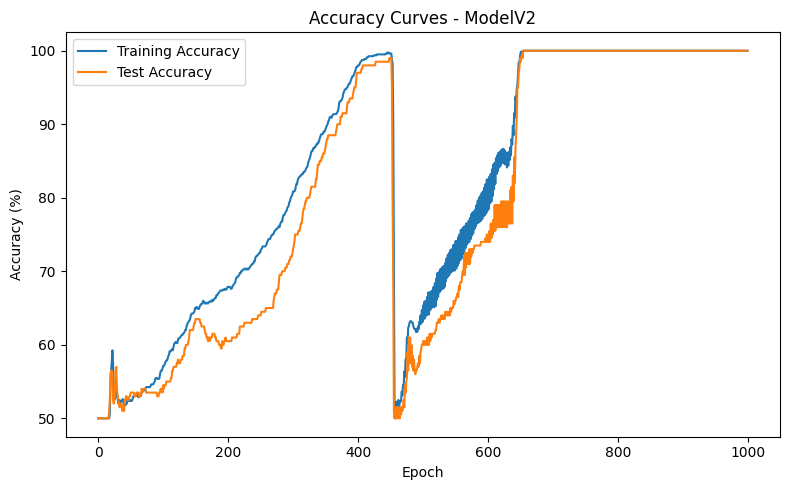

In [29]:
# Plot loss and accuracy curves
plot_loss_curves(train_losses_v2, test_losses_v2, title="ModelV2")
plot_acc_curves(train_acc_v2, test_acc_v2, title="ModelV2")

### ModelV2 Results and Analysis

With ReLU activation, the model learns a non-linear decision boundary.

The network successfully separates the two circles and achieves high accuracy.  
Loss decreases steadily during training, indicating effective learning.

This demonstrates the importance of activation functions in neural networks.

## 10. Optimizer Comparison — SGD vs Adam

Two optimization methods are compared:

SGD:
- Simple gradient descent updates  
- May require careful learning rate tuning  

Adam:
- Adaptive learning rates  
- Typically faster convergence  

Both optimizers can achieve strong performance, but Adam often reaches high accuracy more quickly.

In [30]:
# Train with Adam optimizer
torch.manual_seed(42)
model_v2_adam = ModelV2().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_adam = torch.optim.Adam(params=model_v2_adam.parameters(), lr=0.01)
epochs_adam = 1000

print("Training ModelV2 with Adam optimizer...")
print("=" * 80)
train_losses_adam, train_acc_adam, test_losses_adam, test_acc_adam = train_and_test_loop(
    model=model_v2_adam, epochs=epochs_adam,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    loss_fn=loss_fn, optimizer=optimizer_adam
)

Training ModelV2 with Adam optimizer...
Epoch: 0 | Loss: 0.69615, Accuracy: 50.00% | Test loss: 0.69079, Test acc: 61.50%
Epoch: 10 | Loss: 0.63054, Accuracy: 74.00% | Test loss: 0.62801, Test acc: 89.00%
Epoch: 20 | Loss: 0.32797, Accuracy: 99.50% | Test loss: 0.33977, Test acc: 94.00%
Epoch: 30 | Loss: 0.06320, Accuracy: 100.00% | Test loss: 0.07978, Test acc: 100.00%


Epoch: 40 | Loss: 0.00960, Accuracy: 100.00% | Test loss: 0.01870, Test acc: 100.00%
Epoch: 50 | Loss: 0.00302, Accuracy: 100.00% | Test loss: 0.00931, Test acc: 100.00%
Epoch: 60 | Loss: 0.00163, Accuracy: 100.00% | Test loss: 0.00652, Test acc: 100.00%
Epoch: 70 | Loss: 0.00117, Accuracy: 100.00% | Test loss: 0.00557, Test acc: 100.00%


Epoch: 80 | Loss: 0.00094, Accuracy: 100.00% | Test loss: 0.00502, Test acc: 100.00%
Epoch: 90 | Loss: 0.00081, Accuracy: 100.00% | Test loss: 0.00467, Test acc: 100.00%
Epoch: 100 | Loss: 0.00073, Accuracy: 100.00% | Test loss: 0.00438, Test acc: 100.00%
Epoch: 110 | Loss: 0.00067, Accuracy: 100.00% | Test loss: 0.00405, Test acc: 100.00%


Epoch: 120 | Loss: 0.00061, Accuracy: 100.00% | Test loss: 0.00387, Test acc: 100.00%
Epoch: 130 | Loss: 0.00056, Accuracy: 100.00% | Test loss: 0.00370, Test acc: 100.00%
Epoch: 140 | Loss: 0.00052, Accuracy: 100.00% | Test loss: 0.00354, Test acc: 100.00%
Epoch: 150 | Loss: 0.00048, Accuracy: 100.00% | Test loss: 0.00342, Test acc: 100.00%


Epoch: 160 | Loss: 0.00044, Accuracy: 100.00% | Test loss: 0.00328, Test acc: 100.00%
Epoch: 170 | Loss: 0.00041, Accuracy: 100.00% | Test loss: 0.00317, Test acc: 100.00%
Epoch: 180 | Loss: 0.00039, Accuracy: 100.00% | Test loss: 0.00305, Test acc: 100.00%
Epoch: 190 | Loss: 0.00036, Accuracy: 100.00% | Test loss: 0.00296, Test acc: 100.00%


...

Epoch: 800 | Loss: 0.00004, Accuracy: 100.00% | Test loss: 0.00112, Test acc: 100.00%
Epoch: 810 | Loss: 0.00004, Accuracy: 100.00% | Test loss: 0.00113, Test acc: 100.00%
Epoch: 820 | Loss: 0.00004, Accuracy: 100.00% | Test loss: 0.00113, Test acc: 100.00%
Epoch: 830 | Loss: 0.00004, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%


Epoch: 840 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00110, Test acc: 100.00%
Epoch: 850 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%
Epoch: 860 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%
Epoch: 870 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%


Epoch: 880 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00112, Test acc: 100.00%
Epoch: 890 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%
Epoch: 900 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%
Epoch: 910 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00112, Test acc: 100.00%


Epoch: 920 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00111, Test acc: 100.00%
Epoch: 930 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00110, Test acc: 100.00%
Epoch: 940 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00110, Test acc: 100.00%
Epoch: 950 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00109, Test acc: 100.00%


Epoch: 960 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00108, Test acc: 100.00%
Epoch: 970 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00109, Test acc: 100.00%
Epoch: 980 | Loss: 0.00002, Accuracy: 100.00% | Test loss: 0.00108, Test acc: 100.00%
Epoch: 990 | Loss: 0.00002, Accuracy: 100.00% | Test loss: 0.00109, Test acc: 100.00%


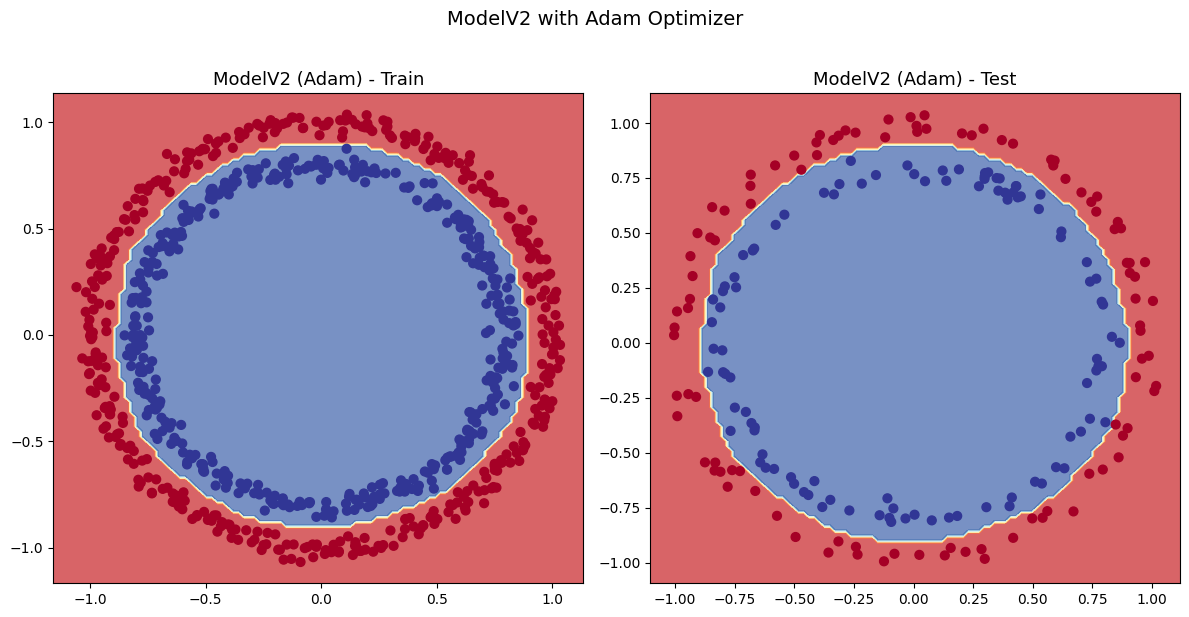

In [31]:
# Plot decision boundaries for Adam
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("ModelV2 (Adam) - Train", fontsize=13)
plot_decision_boundary(model_v2_adam, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("ModelV2 (Adam) - Test", fontsize=13)
plot_decision_boundary(model_v2_adam, X_test, y_test)
plt.suptitle("ModelV2 with Adam Optimizer", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

model_v2_adam.to(device);

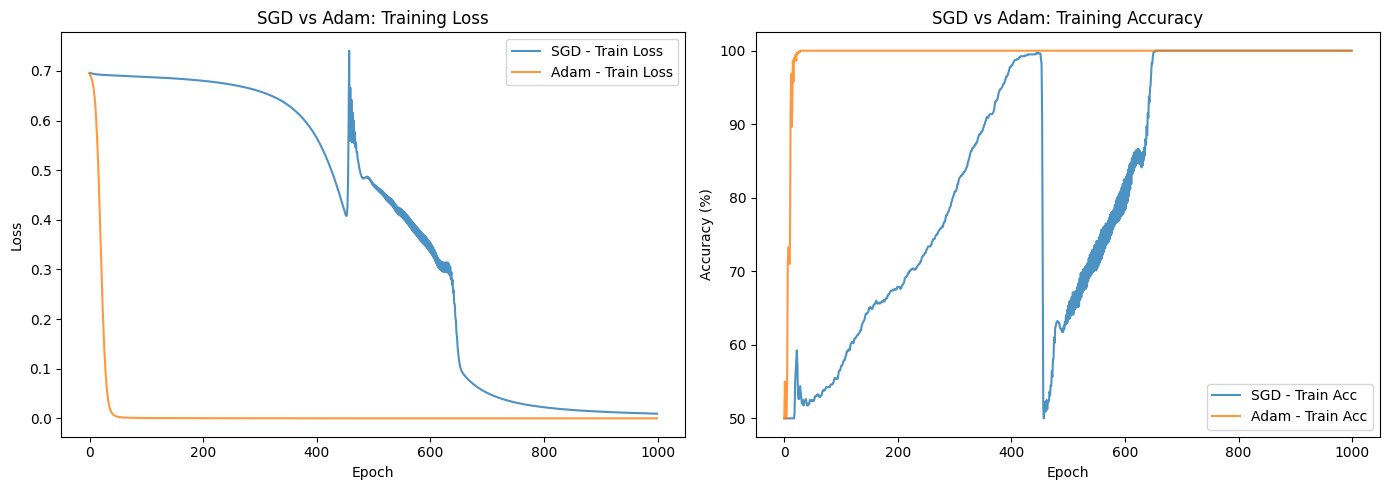

In [32]:
# Compare SGD vs Adam convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(train_losses_v2, label='SGD - Train Loss', alpha=0.8)
axes[0].plot(train_losses_adam, label='Adam - Train Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('SGD vs Adam: Training Loss')
axes[0].legend()

# Accuracy comparison
axes[1].plot(train_acc_v2, label='SGD - Train Acc', alpha=0.8)
axes[1].plot(train_acc_adam, label='Adam - Train Acc', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('SGD vs Adam: Training Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [33]:
# Print final comparison
print("Optimizer Comparison (Final Epoch Results)")
print("=" * 60)
print(f"{'Metric':<30} {'SGD':>12} {'Adam':>12}")
print("-" * 60)
print(f"{'Final Train Loss':<30} {train_losses_v2[-1]:>12.5f} {train_losses_adam[-1]:>12.5f}")
print(f"{'Final Test Loss':<30} {test_losses_v2[-1]:>12.5f} {test_losses_adam[-1]:>12.5f}")
print(f"{'Final Train Accuracy (%)':<30} {train_acc_v2[-1]:>12.2f} {train_acc_adam[-1]:>12.2f}")
print(f"{'Final Test Accuracy (%)':<30} {test_acc_v2[-1]:>12.2f} {test_acc_adam[-1]:>12.2f}")

Optimizer Comparison (Final Epoch Results)
Metric                                  SGD         Adam
------------------------------------------------------------
Final Train Loss                    0.00940      0.00002
Final Test Loss                     0.02227      0.00108
Final Train Accuracy (%)             100.00       100.00
Final Test Accuracy (%)              100.00       100.00


### Adam vs SGD Analysis

Adam typically converges faster than SGD because it uses adaptive learning rates for each parameter, effectively adjusting the step size based on the history of gradients. For this task, Adam often reaches high accuracy in fewer epochs. SGD, while simpler, may require more careful learning rate tuning and more epochs to reach the same performance. Both can achieve strong results on this dataset, but Adam is generally more robust to the choice of hyperparameters.

## 11. Overall Model Comparison

We compare models based on:

- Architecture  
- Presence of activation functions  
- Final test accuracy  

The comparison highlights how non-linear transformations significantly improve performance.

In [34]:
# Summary table of all models
print("Complete Model Comparison")
print("=" * 75)
print(f"{'Model':<20} {'Architecture':<25} {'Activation':<10} {'Final Test Acc':>15}")
print("-" * 75)
print(f"{'ModelV0':<20} {'2->5->1':<25} {'None':<10} {test_acc_v0[-1]:>14.2f}%")
print(f"{'ModelV1':<20} {'2->15->15->1':<25} {'None':<10} {test_acc_v1[-1]:>14.2f}%")
print(f"{'ModelV2 (SGD)':<20} {'2->64->64->10->1':<25} {'ReLU':<10} {test_acc_v2[-1]:>14.2f}%")
print(f"{'ModelV2 (Adam)':<20} {'2->64->64->10->1':<25} {'ReLU':<10} {test_acc_adam[-1]:>14.2f}%")

Complete Model Comparison
Model                Architecture              Activation  Final Test Acc
---------------------------------------------------------------------------
ModelV0              2->5->1                   None                46.50%
ModelV1              2->15->15->1              None                46.00%
ModelV2 (SGD)        2->64->64->10->1          ReLU               100.00%
ModelV2 (Adam)       2->64->64->10->1          ReLU               100.00%


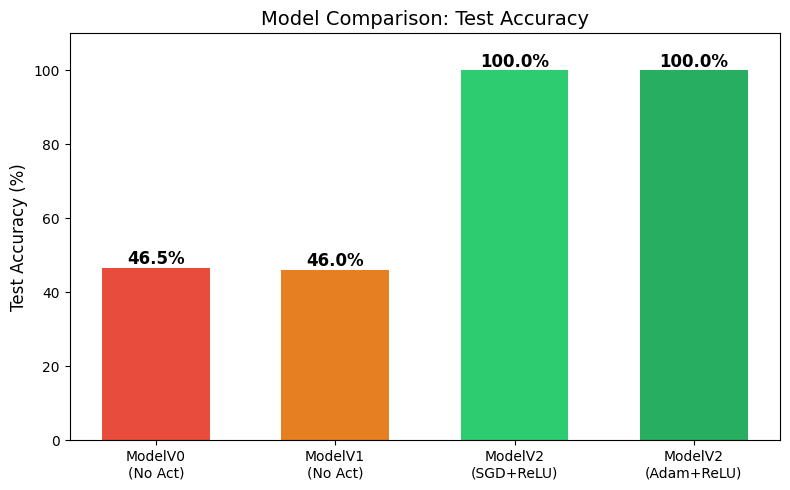

In [35]:
# Visual comparison of test accuracies
models = ['ModelV0\n(No Act)', 'ModelV1\n(No Act)', 'ModelV2\n(SGD+ReLU)', 'ModelV2\n(Adam+ReLU)']
accuracies = [test_acc_v0[-1], test_acc_v1[-1], test_acc_v2[-1], test_acc_adam[-1]]
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.6)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Comparison: Test Accuracy', fontsize=14)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

## 12. Discussion and Conclusion

This experiment demonstrates that neural networks require non-linear activation functions to learn complex patterns.

Models without activation functions behave like linear classifiers, regardless of depth or number of parameters.  
Such models cannot solve non-linear problems like circular classification.

Once non-linearity is introduced through ReLU, the network successfully learns the circular decision boundary and achieves high accuracy.

Optimizer choice affects training speed, but activation functions determine whether the model can learn the task at all.

### Key Takeaways

- Linear networks cannot solve non-linear classification tasks  
- Activation functions are essential for representation learning  
- Model complexity alone does not guarantee performance  
- Adaptive optimizers can accelerate convergence  

### Future Improvements

- Hyperparameter tuning  
- Different activation functions  
- Regularization techniques  
- Testing on additional datasets  